### Adebola Ajayi, Advanced Big Data and Data Mining (MSCS-634-M50) Lab2

%pip install pandas 
%pip install matplotlib 
%pip install scikit-learn

In [24]:
import pandas as pd
from sklearn.datasets import load_wine

wine_data = load_wine(as_frame=True)
wine_df = wine_data.frame

print(wine_df.head())

print("Shape of the Wine DataFrame:", wine_df.shape)

print("\nSummary Statistics:")
print(wine_df.describe())

print("\nMissing Values:")
print(wine_df.isnull().sum())

print("\nClass Distribution:")
print(wine_df["target"].value_counts())

print("\nClass Distribution Percentage:")
print(wine_df["target"].value_counts(normalize=True) * 100)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [25]:
from sklearn.model_selection import train_test_split

X = wine_df.drop("target", axis=1)
y = wine_df["target"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training feature shape: (142, 13)
Testing feature shape: (36, 13)
Training target shape: (142,)
Testing target shape: (36,)


In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = [1, 5, 11, 15, 21]

results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        "k": k,
        "Accuracy": accuracy
    })

accuracy_df = pd.DataFrame(results)
accuracy_df["Accuracy (%)"] = accuracy_df["Accuracy"] * 100

print(accuracy_df)

    k  Accuracy  Accuracy (%)
0   1  0.972222     97.222222
1   5  0.972222     97.222222
2  11  1.000000    100.000000
3  15  1.000000    100.000000
4  21  1.000000    100.000000


In [27]:
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

radius_values = [350, 400, 450, 500, 550, 600]

results = []

for radius in radius_values:

    rnn = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label="most_frequent"
    )

    rnn.fit(X_train, y_train)
    y_pred = rnn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results.append({
        "Radius": radius,
        "Accuracy": accuracy
    })

rnn_accuracy_df = pd.DataFrame(results)

rnn_accuracy_df["Accuracy (%)"] = (
    rnn_accuracy_df["Accuracy"] * 100
)

print(rnn_accuracy_df)

   Radius  Accuracy  Accuracy (%)
0     350  0.722222     72.222222
1     400  0.694444     69.444444
2     450  0.694444     69.444444
3     500  0.694444     69.444444
4     550  0.666667     66.666667
5     600  0.666667     66.666667


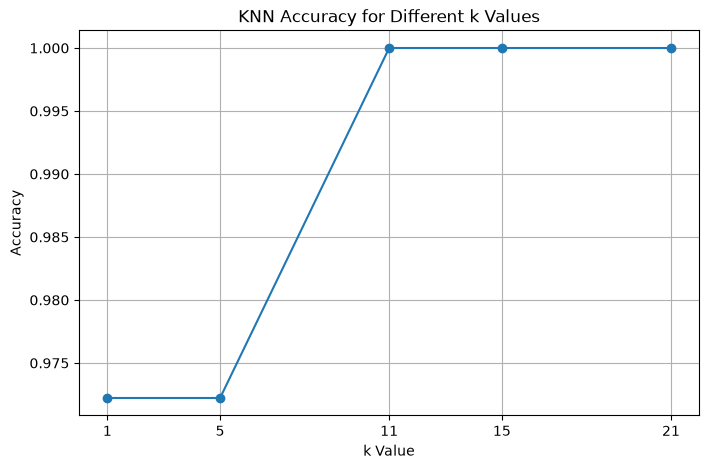

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    accuracy_df["k"],
    accuracy_df["Accuracy"],
    marker="o"
)

plt.title("KNN Accuracy for Different k Values")
plt.xlabel("k Value")
plt.ylabel("Accuracy")
plt.xticks(accuracy_df["k"])
plt.grid(True)

plt.show()

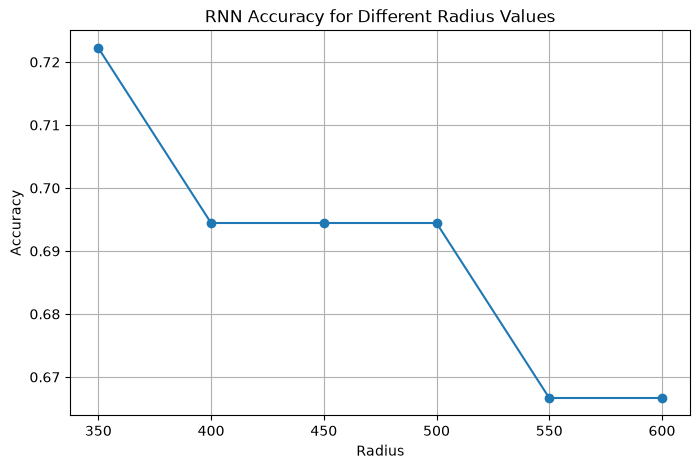

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    rnn_accuracy_df["Radius"],
    rnn_accuracy_df["Accuracy"],
    marker="o"
)

plt.title("RNN Accuracy for Different Radius Values")
plt.xlabel("Radius")
plt.ylabel("Accuracy")
plt.xticks(rnn_accuracy_df["Radius"])
plt.grid(True)

plt.show()

In [30]:
print("KNN Results:")
print(accuracy_df)

print("\nRNN Results:")
print(rnn_accuracy_df)

best_knn = accuracy_df.loc[accuracy_df["Accuracy"].idxmax()]

best_rnn = rnn_accuracy_df.loc[rnn_accuracy_df["Accuracy"].idxmax()]

print("Best KNN:")
print("k =", int(best_knn["k"]))
print("Accuracy =", round(best_knn["Accuracy"] * 100, 2), "%")

print("\nBest RNN:")
print("Radius =", int(best_rnn["Radius"]))
print("Accuracy =", round(best_rnn["Accuracy"] * 100, 2), "%")

KNN Results:
    k  Accuracy  Accuracy (%)
0   1  0.972222     97.222222
1   5  0.972222     97.222222
2  11  1.000000    100.000000
3  15  1.000000    100.000000
4  21  1.000000    100.000000

RNN Results:
   Radius  Accuracy  Accuracy (%)
0     350  0.722222     72.222222
1     400  0.694444     69.444444
2     450  0.694444     69.444444
3     500  0.694444     69.444444
4     550  0.666667     66.666667
5     600  0.666667     66.666667
Best KNN:
k = 11
Accuracy = 100.0 %

Best RNN:
Radius = 350
Accuracy = 72.22 %


Looking at the results, the accuracy of both KNN and RNN changed depending on the neighbor setting that was used. For KNN, the highest accuracy occurred when k = 11, with an accuracy of 100.%. For RNN, the best result occurred with a radius of 350, giving an accuracy of 72.22%. This shows that choosing the right value for k or radius can have a noticeable effect on model performance.

One thing I noticed with KNN is that smaller k values depend heavily on only a few nearby data points, which can make the model more sensitive to noise. As k increases, more neighbors influence the prediction, which can make the model more stable but may eventually reduce accuracy if too many unrelated points are included. RNN behaves similarly, except instead of selecting a fixed number of neighbors, it includes every point within the chosen radius.

In this dataset, KNN performed better than RNN based on the highest test accuracy. This suggests that using a fixed number of nearby observations was a better fit for the data than using a fixed distance.